<a href="https://colab.research.google.com/github/Kommera-Harihansika/NexTune/blob/main/earphones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload your headphones_raw.csv file


Saving headphones_raw.csv to headphones_raw.csv

✅ Loaded 148 products
         asin                                               name  \
0  B0BW8TXJJ2  Boat Nirvana Ion, 120HRS Battery, Crystal Bion...   
1  B0FC2YFSN4  Boat Airdopes 219, 4Mics ENx, 40H Battery, Bes...   
2  B0GS6113PR  VarniADR Wireless Earbuds Bluetooth 5.3 TWS Ea...   
3  B0GS5N3LPL  PrimeeVaultt Wireless In Ear Earbuds, Bluetoot...   
4  B08TV2P1N8  Boat Rockerz 255 Pro+, 60HRS Battery, Fast Cha...   

          brand  price              rating   reviews  \
0          Boat   1599  4.1 out of 5 stars   13140.0   
1          Boat   1099  3.9 out of 5 stars    4363.0   
2      VarniADR    351  3.9 out of 5 stars      15.0   
3  PrimeeVaultt    269  2.8 out of 5 stars      11.0   
4          Boat   1049  4.0 out of 5 stars  148496.0   

                                                link  
0  https://www.amazon.in/sspa/click?ie=UTF8&spc=M...  
1  https://www.amazon.in/sspa/click?ie=UTF8&spc=M...  
2  https://www.ama

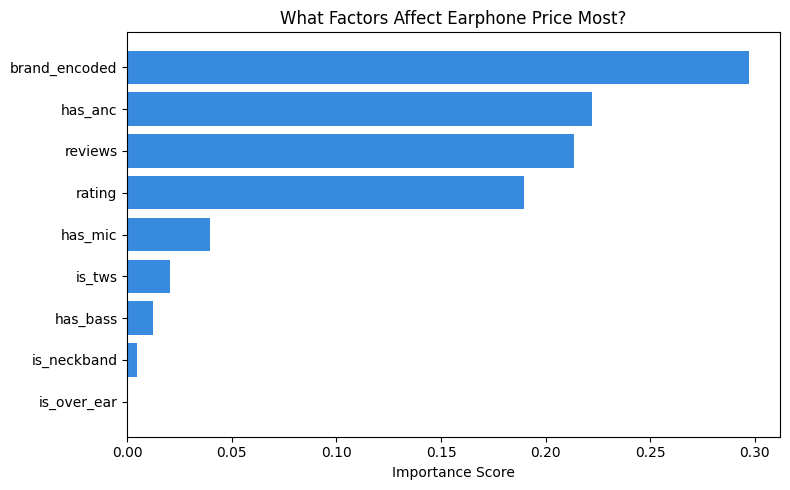

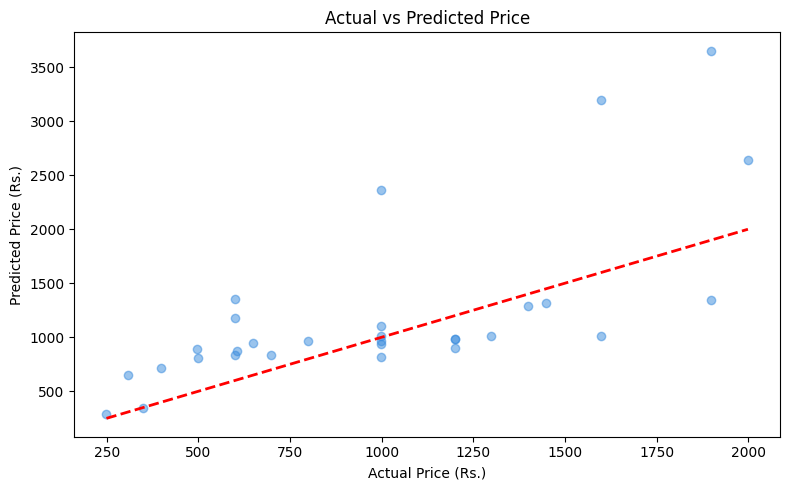

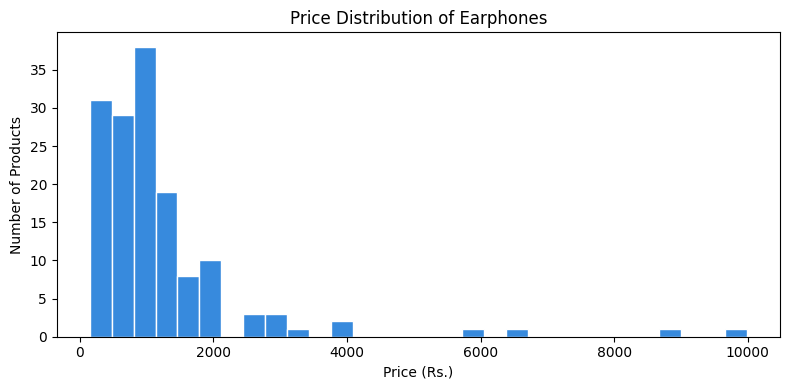


✅ Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!

      PREDICTION RESULT
  Brand      : boAt
  ANC        : Yes
  TWS        : Yes
  Mic        : Yes
  Neckband   : No
  Over-Ear   : No
  Extra Bass : Yes
----------------------------------------
  Predicted  : Rs.3,915
  Range      : Rs.3,524 – Rs.4,307


np.float64(3915.415)

In [1]:
# ============================================================
#   STEP 1 — Install libraries
# ============================================================
!pip install pandas scikit-learn matplotlib seaborn -q

# ============================================================
#   STEP 2 — Upload your CSV file
# ============================================================
from google.colab import files
print("Upload your headphones_raw.csv file")
uploaded = files.upload()

# ============================================================
#   STEP 3 — Load and Clean Data
# ============================================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import io

# Load uploaded file
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n✅ Loaded {len(df)} products")
print(df.head())

# ── Clean price ──
df["price"] = (df["price"]
               .astype(str)
               .str.replace(",", "")
               .str.extract(r"(\d+)")[0]
               .astype(float))

# ── Clean rating ──
df["rating"] = (df["rating"]
                .astype(str)
                .str.extract(r"([\d.]+)")[0]
                .astype(float))
df["rating"] = df["rating"].fillna(df["rating"].mean())

# ── Clean reviews ──
df["reviews"] = (df["reviews"]
                 .astype(str)
                 .str.replace(",", "")
                 .str.extract(r"(\d+)")[0]
                 .fillna(0)
                 .astype(int))

# ── Extract features from product name ──
df["has_anc"]     = df["name"].str.contains("ANC|noise cancel|active noise", case=False, na=False).astype(int)
df["is_tws"]      = df["name"].str.contains("TWS|truly wireless|true wireless", case=False, na=False).astype(int)
df["has_mic"]     = df["name"].str.contains("mic|microphone", case=False, na=False).astype(int)
df["is_neckband"] = df["name"].str.contains("neckband|neck band", case=False, na=False).astype(int)
df["is_over_ear"] = df["name"].str.contains("over.ear|over ear|overhead", case=False, na=False).astype(int)
df["has_bass"]    = df["name"].str.contains("bass|extra bass", case=False, na=False).astype(int)

# ── Encode brand ──
df["brand"] = df["brand"].fillna("Unknown")
le = LabelEncoder()
df["brand_encoded"] = le.fit_transform(df["brand"].astype(str))

# ── Remove outliers ──
df = df[(df["price"] > 100) & (df["price"] < 50000)]
df = df.dropna(subset=["price"])

print(f"\n✅ Clean dataset: {len(df)} products")
print(df[["name","brand","price","rating","reviews"]].head(10))

# ============================================================
#   STEP 4 — Train ML Model
# ============================================================
features = [
    "rating", "reviews", "has_anc", "is_tws",
    "has_mic", "is_neckband", "is_over_ear",
    "has_bass", "brand_encoded"
]

X = df[features]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining on {len(X_train)} products...")
print(f"Testing  on {len(X_test)}  products...")

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# ============================================================
#   STEP 5 — Evaluate Model
# ============================================================
preds    = model.predict(X_test)
mae      = mean_absolute_error(y_test, preds)
r2       = r2_score(y_test, preds)
accuracy = max(0, 100 - (mae / y_test.mean() * 100))

print("\n" + "=" * 45)
print("        MODEL PERFORMANCE RESULTS")
print("=" * 45)
print(f"  Mean Absolute Error : Rs.{mae:.2f}")
print(f"  R² Score            : {r2:.3f}")
print(f"  Approx Accuracy     : {accuracy:.1f}%")
print("=" * 45)

# ============================================================
#   STEP 6 — Charts
# ============================================================

# Chart 1 — Feature Importance
plt.figure(figsize=(8, 5))
importance_df = pd.DataFrame({
    "Feature":    features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)
plt.barh(importance_df["Feature"], importance_df["Importance"], color="#378ADD")
plt.xlabel("Importance Score")
plt.title("What Factors Affect Earphone Price Most?")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

# Chart 2 — Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, preds, alpha=0.5, color="#378ADD")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Price (Rs.)")
plt.ylabel("Predicted Price (Rs.)")
plt.title("Actual vs Predicted Price")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()

# Chart 3 — Price Distribution
plt.figure(figsize=(8, 4))
plt.hist(df["price"], bins=30, color="#378ADD", edgecolor="white")
plt.xlabel("Price (Rs.)")
plt.ylabel("Number of Products")
plt.title("Price Distribution of Earphones")
plt.tight_layout()
plt.savefig("price_distribution.png")
plt.show()

# ============================================================
#   STEP 7 — Save Model and Download
# ============================================================
with open("price_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("\n✅ Model saved!")

# Download all files
files.download("price_model.pkl")
files.download("label_encoder.pkl")
files.download("feature_importance.png")
files.download("actual_vs_predicted.png")
files.download("price_distribution.png")
print("✅ All files downloaded!")

# ============================================================
#   STEP 8 — Test a Prediction
# ============================================================
def predict_price(brand, has_anc, is_tws, has_mic,
                  is_neckband, is_over_ear, has_bass,
                  rating=4.0, reviews=1000):
    try:
        brand_encoded = le.transform([brand])[0]
    except:
        brand_encoded = 0

    input_df = pd.DataFrame([{
        "rating":        rating,
        "reviews":       reviews,
        "has_anc":       int(has_anc),
        "is_tws":        int(is_tws),
        "has_mic":       int(has_mic),
        "is_neckband":   int(is_neckband),
        "is_over_ear":   int(is_over_ear),
        "has_bass":      int(has_bass),
        "brand_encoded": brand_encoded
    }])

    price = model.predict(input_df)[0]
    print("\n" + "=" * 40)
    print("      PREDICTION RESULT")
    print("=" * 40)
    print(f"  Brand      : {brand}")
    print(f"  ANC        : {'Yes' if has_anc else 'No'}")
    print(f"  TWS        : {'Yes' if is_tws else 'No'}")
    print(f"  Mic        : {'Yes' if has_mic else 'No'}")
    print(f"  Neckband   : {'Yes' if is_neckband else 'No'}")
    print(f"  Over-Ear   : {'Yes' if is_over_ear else 'No'}")
    print(f"  Extra Bass : {'Yes' if has_bass else 'No'}")
    print("-" * 40)
    print(f"  Predicted  : Rs.{price:,.0f}")
    print(f"  Range      : Rs.{price*0.9:,.0f} – Rs.{price*1.1:,.0f}")
    print("=" * 40)
    return price

# ── Change these specs to test your own product ──
predict_price(
    brand       = "boAt",
    has_anc     = True,
    is_tws      = True,
    has_mic     = True,
    is_neckband = False,
    is_over_ear = False,
    has_bass    = True,
    rating      = 4.2,
    reviews     = 5000
)

📂 Upload ALL your CSV files at once (select multiple files)
   Hold Ctrl and click to select multiple files



Saving headphones_raw.csv to headphones_raw (1).csv
✅ Loaded headphones_raw (1).csv — 148 rows

📊 Total combined rows : 148
📁 Files loaded        : 1

Columns found: ['asin', 'name', 'brand', 'price', 'rating', 'reviews', 'link', 'source_file']

First 5 rows:
         asin                                               name  \
0  B0BW8TXJJ2  Boat Nirvana Ion, 120HRS Battery, Crystal Bion...   
1  B0FC2YFSN4  Boat Airdopes 219, 4Mics ENx, 40H Battery, Bes...   
2  B0GS6113PR  VarniADR Wireless Earbuds Bluetooth 5.3 TWS Ea...   
3  B0GS5N3LPL  PrimeeVaultt Wireless In Ear Earbuds, Bluetoot...   
4  B08TV2P1N8  Boat Rockerz 255 Pro+, 60HRS Battery, Fast Cha...   

          brand  price              rating   reviews  \
0          Boat   1599  4.1 out of 5 stars   13140.0   
1          Boat   1099  3.9 out of 5 stars    4363.0   
2      VarniADR    351  3.9 out of 5 stars      15.0   
3  PrimeeVaultt    269  2.8 out of 5 stars      11.0   
4          Boat   1049  4.0 out of 5 stars  148496.

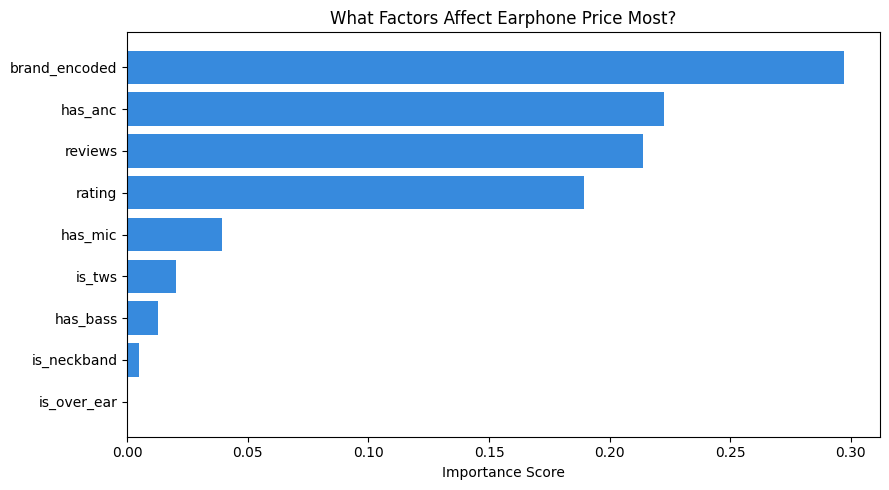

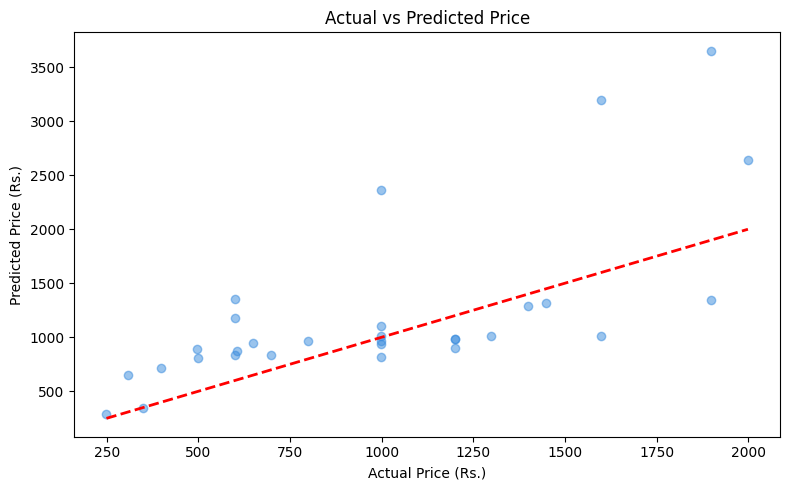

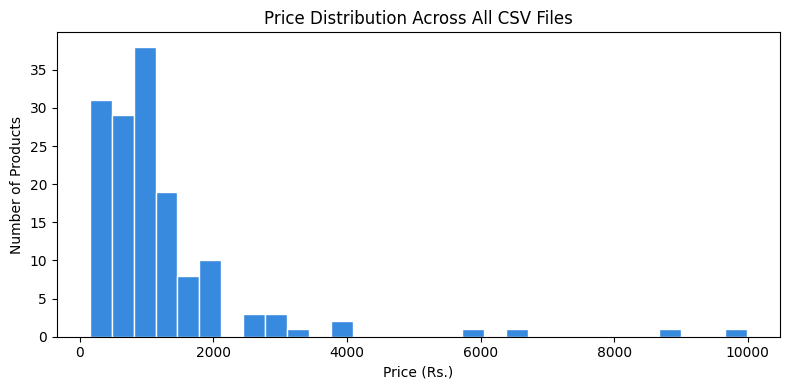

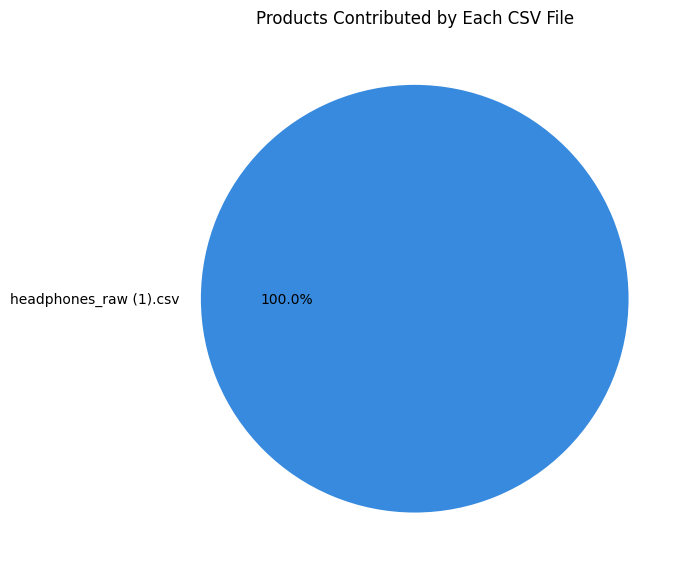

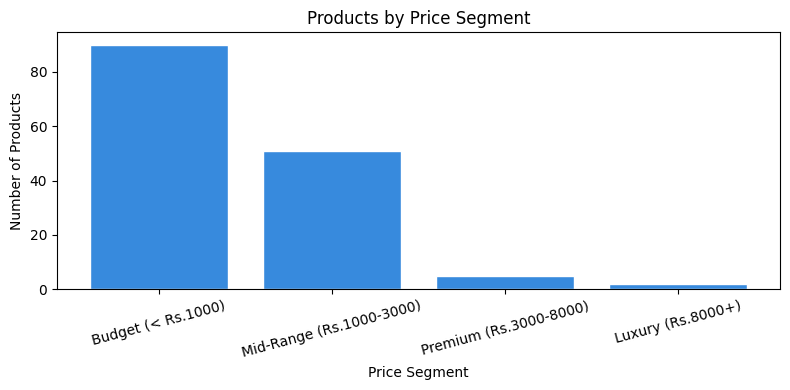


⬇️  Downloading all files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!

       PREDICTION RESULT
  Brand      : boAt
  ANC        : Yes
  TWS        : Yes
  Mic        : Yes
  Neckband   : No
  Over-Ear   : No
  Extra Bass : Yes
----------------------------------------
  Predicted  : Rs.3,915
  Range      : Rs.3,524 – Rs.4,307


np.float64(3915.415)

In [2]:
# ============================================================
#   STEP 1 — Install libraries
# ============================================================
!pip install pandas scikit-learn matplotlib seaborn -q

# ============================================================
#   STEP 2 — Upload MULTIPLE CSV files
# ============================================================
from google.colab import files
import pandas as pd
import numpy as np
import io

print("📂 Upload ALL your CSV files at once (select multiple files)")
print("   Hold Ctrl and click to select multiple files\n")
uploaded = files.upload()

# ============================================================
#   STEP 3 — Combine all CSV files into one dataframe
# ============================================================
all_dfs = []

for filename, content in uploaded.items():
    try:
        df_temp = pd.read_csv(io.BytesIO(content))
        df_temp["source_file"] = filename  # track which file each row came from
        all_dfs.append(df_temp)
        print(f"✅ Loaded {filename} — {len(df_temp)} rows")
    except Exception as e:
        print(f"❌ Failed to load {filename}: {e}")

# Combine all into one
df = pd.concat(all_dfs, ignore_index=True)
print(f"\n📊 Total combined rows : {len(df)}")
print(f"📁 Files loaded        : {len(all_dfs)}")
print(f"\nColumns found: {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())

# ============================================================
#   STEP 4 — Clean Combined Data
# ============================================================
from sklearn.preprocessing import LabelEncoder

print("\n🔧 Cleaning data...")

# ── Price ──
df["price"] = (df["price"]
               .astype(str)
               .str.replace(",", "")
               .str.extract(r"(\d+)")[0]
               .astype(float))

# ── Rating ──
df["rating"] = (df["rating"]
                .astype(str)
                .str.extract(r"([\d.]+)")[0]
                .astype(float))
df["rating"] = df["rating"].fillna(df["rating"].mean())

# ── Reviews ──
df["reviews"] = (df["reviews"]
                 .astype(str)
                 .str.replace(",", "")
                 .str.extract(r"(\d+)")[0]
                 .fillna(0)
                 .astype(int))

# ── Features from product name ──
df["has_anc"]     = df["name"].str.contains("ANC|noise cancel|active noise", case=False, na=False).astype(int)
df["is_tws"]      = df["name"].str.contains("TWS|truly wireless|true wireless", case=False, na=False).astype(int)
df["has_mic"]     = df["name"].str.contains("mic|microphone", case=False, na=False).astype(int)
df["is_neckband"] = df["name"].str.contains("neckband|neck band", case=False, na=False).astype(int)
df["is_over_ear"] = df["name"].str.contains("over.ear|over ear|overhead", case=False, na=False).astype(int)
df["has_bass"]    = df["name"].str.contains("bass|extra bass", case=False, na=False).astype(int)

# ── Brand encoding ──
df["brand"] = df["brand"].fillna("Unknown")
le = LabelEncoder()
df["brand_encoded"] = le.fit_transform(df["brand"].astype(str))

# ── Remove duplicates across files ──
before = len(df)
if "asin" in df.columns:
    df = df.drop_duplicates(subset=["asin"])
else:
    df = df.drop_duplicates(subset=["name", "price"])
after = len(df)
print(f"Removed {before - after} duplicate products across files")

# ── Remove price outliers ──
df = df[(df["price"] > 100) & (df["price"] < 50000)]
df = df.dropna(subset=["price"])

print(f"\n✅ Final clean dataset: {len(df)} unique products")

# Show breakdown by source file
print("\n📁 Products per file:")
print(df["source_file"].value_counts().to_string())

# ============================================================
#   STEP 5 — Show Combined Data Table
# ============================================================
print("\n📋 Combined Data Sample (first 15 rows):")
display_df = df[["name", "brand", "price", "rating", "reviews", "source_file"]].copy()
display_df["name"] = display_df["name"].str[:45]
display_df["price"] = display_df["price"].apply(lambda x: f"Rs.{int(x):,}")
print(display_df.head(15).to_string(index=False))

# ============================================================
#   STEP 6 — Train ML Model
# ============================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    "rating", "reviews", "has_anc", "is_tws",
    "has_mic", "is_neckband", "is_over_ear",
    "has_bass", "brand_encoded"
]

X = df[features]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n🤖 Training model...")
print(f"   Training samples : {len(X_train)}")
print(f"   Testing  samples : {len(X_test)}")

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("✅ Model trained!")

# ============================================================
#   STEP 7 — Evaluate Model
# ============================================================
preds    = model.predict(X_test)
mae      = mean_absolute_error(y_test, preds)
r2       = r2_score(y_test, preds)
accuracy = max(0, 100 - (mae / y_test.mean() * 100))

print("\n" + "=" * 45)
print("        MODEL PERFORMANCE RESULTS")
print("=" * 45)
print(f"  Total Products Used : {len(df)}")
print(f"  CSV Files Combined  : {len(all_dfs)}")
print(f"  Mean Absolute Error : Rs.{mae:.2f}")
print(f"  R² Score            : {r2:.3f}")
print(f"  Approx Accuracy     : {accuracy:.1f}%")
print("=" * 45)

# ============================================================
#   STEP 8 — Charts
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1 — Feature Importance
plt.figure(figsize=(9, 5))
importance_df = pd.DataFrame({
    "Feature":    features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)
plt.barh(importance_df["Feature"], importance_df["Importance"], color="#378ADD")
plt.xlabel("Importance Score")
plt.title("What Factors Affect Earphone Price Most?")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

# Chart 2 — Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, preds, alpha=0.5, color="#378ADD")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Price (Rs.)")
plt.ylabel("Predicted Price (Rs.)")
plt.title("Actual vs Predicted Price")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()

# Chart 3 — Price Distribution
plt.figure(figsize=(8, 4))
plt.hist(df["price"], bins=30, color="#378ADD", edgecolor="white")
plt.xlabel("Price (Rs.)")
plt.ylabel("Number of Products")
plt.title("Price Distribution Across All CSV Files")
plt.tight_layout()
plt.savefig("price_distribution.png")
plt.show()

# Chart 4 — Products per file (pie chart)
plt.figure(figsize=(7, 7))
file_counts = df["source_file"].value_counts()
plt.pie(file_counts.values,
        labels=file_counts.index,
        autopct="%1.1f%%",
        colors=["#378ADD", "#1D9E75", "#D85A30", "#BA7517", "#D4537E"])
plt.title("Products Contributed by Each CSV File")
plt.tight_layout()
plt.savefig("files_contribution.png")
plt.show()

# Chart 5 — Price segment breakdown
def segment(p):
    if p < 1000:   return "Budget (< Rs.1000)"
    elif p < 3000: return "Mid-Range (Rs.1000-3000)"
    elif p < 8000: return "Premium (Rs.3000-8000)"
    else:          return "Luxury (Rs.8000+)"

df["segment"] = df["price"].apply(segment)
plt.figure(figsize=(8, 4))
seg_counts = df["segment"].value_counts()
plt.bar(seg_counts.index, seg_counts.values, color="#378ADD", edgecolor="white")
plt.xlabel("Price Segment")
plt.ylabel("Number of Products")
plt.title("Products by Price Segment")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("price_segments.png")
plt.show()

# ============================================================
#   STEP 9 — Save and Download Model
# ============================================================
import pickle

with open("price_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

# Save combined clean CSV
df.to_csv("combined_clean_data.csv", index=False)

print("\n⬇️  Downloading all files...")
files.download("price_model.pkl")
files.download("label_encoder.pkl")
files.download("combined_clean_data.csv")
files.download("feature_importance.png")
files.download("actual_vs_predicted.png")
files.download("price_distribution.png")
files.download("files_contribution.png")
files.download("price_segments.png")
print("✅ All files downloaded!")

# ============================================================
#   STEP 10 — Test a Prediction
# ============================================================
def predict_price(brand, has_anc, is_tws, has_mic,
                  is_neckband, is_over_ear, has_bass,
                  rating=4.0, reviews=1000):
    try:
        brand_encoded = le.transform([brand])[0]
    except:
        brand_encoded = 0

    input_df = pd.DataFrame([{
        "rating":        rating,
        "reviews":       reviews,
        "has_anc":       int(has_anc),
        "is_tws":        int(is_tws),
        "has_mic":       int(has_mic),
        "is_neckband":   int(is_neckband),
        "is_over_ear":   int(is_over_ear),
        "has_bass":      int(has_bass),
        "brand_encoded": brand_encoded
    }])

    price = model.predict(input_df)[0]
    print("\n" + "=" * 40)
    print("       PREDICTION RESULT")
    print("=" * 40)
    print(f"  Brand      : {brand}")
    print(f"  ANC        : {'Yes' if has_anc else 'No'}")
    print(f"  TWS        : {'Yes' if is_tws else 'No'}")
    print(f"  Mic        : {'Yes' if has_mic else 'No'}")
    print(f"  Neckband   : {'Yes' if is_neckband else 'No'}")
    print(f"  Over-Ear   : {'Yes' if is_over_ear else 'No'}")
    print(f"  Extra Bass : {'Yes' if has_bass else 'No'}")
    print("-" * 40)
    print(f"  Predicted  : Rs.{price:,.0f}")
    print(f"  Range      : Rs.{price*0.9:,.0f} – Rs.{price*1.1:,.0f}")
    print("=" * 40)
    return price

# ── Test with sample product ──
predict_price(
    brand       = "boAt",
    has_anc     = True,
    is_tws      = True,
    has_mic     = True,
    is_neckband = False,
    is_over_ear = False,
    has_bass    = True,
    rating      = 4.2,
    reviews     = 5000
)

Mounted at /content/drive
Found 3 CSV files:
  → headphones_raw.csv
  → indian_wireless_headphones_scraped_data.csv
  → amazon_earphones_market_data (1).csv
✅ Loaded headphones_raw.csv — 148 rows
✅ Loaded indian_wireless_headphones_scraped_data.csv — 44 rows
✅ Loaded amazon_earphones_market_data (1).csv — 250 rows

✅ Total combined rows : 442
📁 Files loaded        : 3

🔧 Cleaning data...
Removed 293 duplicates

✅ Final clean dataset : 148 unique products

📁 Products per file:
source_file
headphones_raw.csv    148

🤖 Training model...
   Training : 118 products
   Testing  : 30 products

       MODEL PERFORMANCE RESULTS
  Total Products  : 148
  Files Combined  : 3
  MAE             : Rs.405.88
  R² Score        : -0.519
  Accuracy        : 58.8%


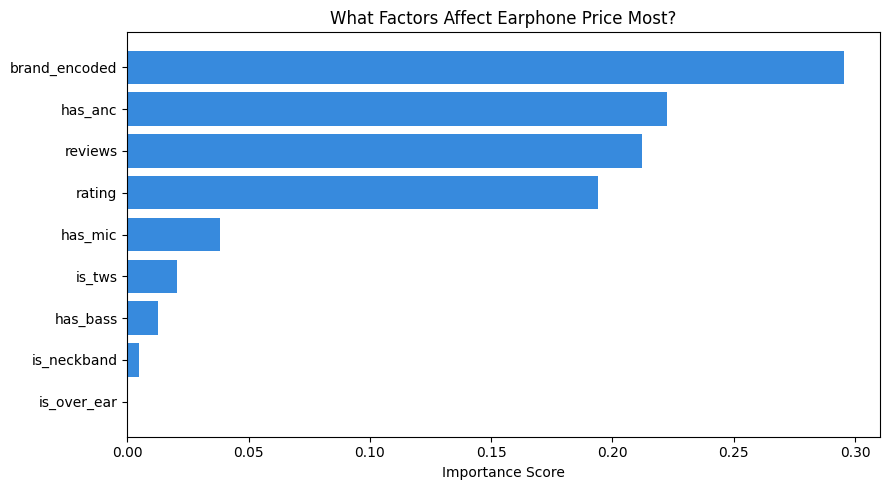

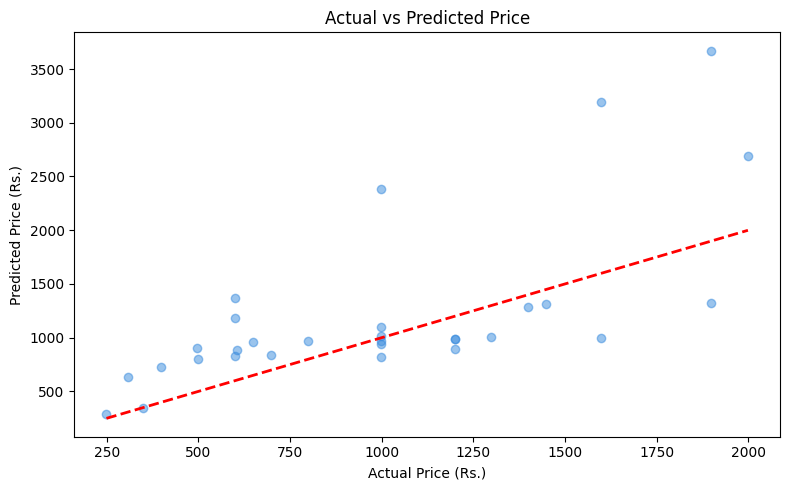

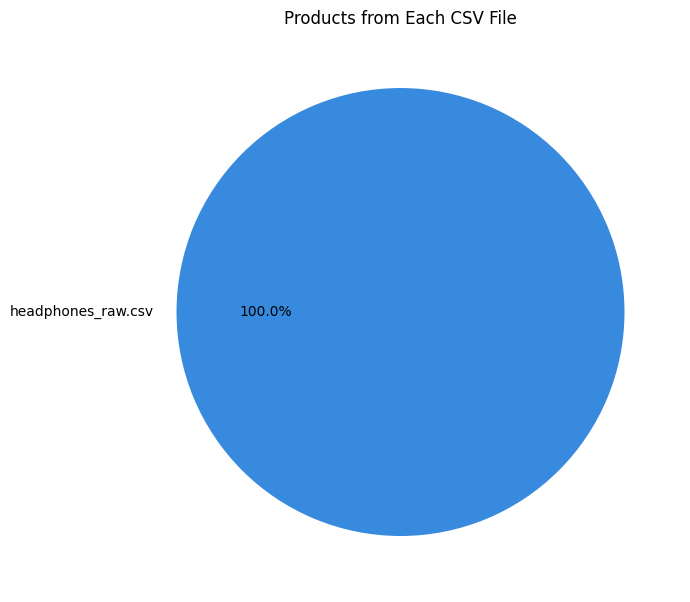


✅ Everything saved to Google Drive folder: earphones_data/
   Files saved:
   → price_model.pkl
   → label_encoder.pkl
   → combined_clean_data.csv
   → feature_importance.png
   → actual_vs_predicted.png
   → files_contribution.png

       PREDICTION RESULT
  Brand      : boAt
  ANC        : Yes
  TWS        : Yes
  Mic        : Yes
  Neckband   : No
  Over-Ear   : No
  Extra Bass : Yes
----------------------------------------
  Predicted  : Rs.3,942
  Range      : Rs.3,548 – Rs.4,336


In [3]:
# ============================================================
#   STEP 1 — Install libraries
# ============================================================
!pip install pandas scikit-learn matplotlib seaborn -q

# ============================================================
#   STEP 2 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
#   STEP 3 — Load ALL CSV files from a Drive folder
# ============================================================
import pandas as pd
import numpy as np
import os
import glob

# ── PUT ALL YOUR CSV FILES IN ONE GOOGLE DRIVE FOLDER ──
# Change this path to your folder name
FOLDER_PATH = "/content/drive/MyDrive/earphones_data/"

# Find all CSV files in that folder
csv_files = glob.glob(FOLDER_PATH + "*.csv")
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  → {os.path.basename(f)}")

# Load and combine all
all_dfs = []
for filepath in csv_files:
    try:
        df_temp = pd.read_csv(filepath)
        df_temp["source_file"] = os.path.basename(filepath)
        all_dfs.append(df_temp)
        print(f"✅ Loaded {os.path.basename(filepath)} — {len(df_temp)} rows")
    except Exception as e:
        print(f"❌ Failed: {filepath} — {e}")

# Combine all into one dataframe
df = pd.concat(all_dfs, ignore_index=True)
print(f"\n✅ Total combined rows : {len(df)}")
print(f"📁 Files loaded        : {len(all_dfs)}")

# ============================================================
#   STEP 4 — Clean Combined Data
# ============================================================
from sklearn.preprocessing import LabelEncoder

print("\n🔧 Cleaning data...")

df["price"] = (df["price"]
               .astype(str)
               .str.replace(",", "")
               .str.extract(r"(\d+)")[0]
               .astype(float))

df["rating"] = (df["rating"]
                .astype(str)
                .str.extract(r"([\d.]+)")[0]
                .astype(float))
df["rating"] = df["rating"].fillna(df["rating"].mean())

df["reviews"] = (df["reviews"]
                 .astype(str)
                 .str.replace(",", "")
                 .str.extract(r"(\d+)")[0]
                 .fillna(0)
                 .astype(int))

df["has_anc"]     = df["name"].str.contains("ANC|noise cancel|active noise", case=False, na=False).astype(int)
df["is_tws"]      = df["name"].str.contains("TWS|truly wireless|true wireless", case=False, na=False).astype(int)
df["has_mic"]     = df["name"].str.contains("mic|microphone", case=False, na=False).astype(int)
df["is_neckband"] = df["name"].str.contains("neckband|neck band", case=False, na=False).astype(int)
df["is_over_ear"] = df["name"].str.contains("over.ear|over ear|overhead", case=False, na=False).astype(int)
df["has_bass"]    = df["name"].str.contains("bass|extra bass", case=False, na=False).astype(int)

df["brand"] = df["brand"].fillna("Unknown")
le = LabelEncoder()
df["brand_encoded"] = le.fit_transform(df["brand"].astype(str))

before = len(df)
if "asin" in df.columns:
    df = df.drop_duplicates(subset=["asin"])
else:
    df = df.drop_duplicates(subset=["name", "price"])
after = len(df)
print(f"Removed {before - after} duplicates")

df = df[(df["price"] > 100) & (df["price"] < 50000)]
df = df.dropna(subset=["price"])

print(f"\n✅ Final clean dataset : {len(df)} unique products")
print("\n📁 Products per file:")
print(df["source_file"].value_counts().to_string())

# ============================================================
#   STEP 5 — Train ML Model
# ============================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    "rating", "reviews", "has_anc", "is_tws",
    "has_mic", "is_neckband", "is_over_ear",
    "has_bass", "brand_encoded"
]

X = df[features]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n🤖 Training model...")
print(f"   Training : {len(X_train)} products")
print(f"   Testing  : {len(X_test)} products")

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

preds    = model.predict(X_test)
mae      = mean_absolute_error(y_test, preds)
r2       = r2_score(y_test, preds)
accuracy = max(0, 100 - (mae / y_test.mean() * 100))

print("\n" + "=" * 45)
print("       MODEL PERFORMANCE RESULTS")
print("=" * 45)
print(f"  Total Products  : {len(df)}")
print(f"  Files Combined  : {len(all_dfs)}")
print(f"  MAE             : Rs.{mae:.2f}")
print(f"  R² Score        : {r2:.3f}")
print(f"  Accuracy        : {accuracy:.1f}%")
print("=" * 45)

# ============================================================
#   STEP 6 — Charts
# ============================================================
import matplotlib.pyplot as plt

# Feature importance
plt.figure(figsize=(9, 5))
importance_df = pd.DataFrame({
    "Feature":    features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)
plt.barh(importance_df["Feature"], importance_df["Importance"], color="#378ADD")
plt.xlabel("Importance Score")
plt.title("What Factors Affect Earphone Price Most?")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/earphones_data/feature_importance.png")
plt.show()

# Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, preds, alpha=0.5, color="#378ADD")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Price (Rs.)")
plt.ylabel("Predicted Price (Rs.)")
plt.title("Actual vs Predicted Price")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/earphones_data/actual_vs_predicted.png")
plt.show()

# Files contribution pie chart
plt.figure(figsize=(7, 7))
file_counts = df["source_file"].value_counts()
plt.pie(file_counts.values,
        labels=file_counts.index,
        autopct="%1.1f%%",
        colors=["#378ADD","#1D9E75","#D85A30","#BA7517","#D4537E"])
plt.title("Products from Each CSV File")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/earphones_data/files_contribution.png")
plt.show()

# ============================================================
#   STEP 7 — Save Model to Google Drive
# ============================================================
import pickle

MODEL_PATH = "/content/drive/MyDrive/earphones_data/"

with open(MODEL_PATH + "price_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open(MODEL_PATH + "label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

df.to_csv(MODEL_PATH + "combined_clean_data.csv", index=False)

print(f"\n✅ Everything saved to Google Drive folder: earphones_data/")
print("   Files saved:")
print("   → price_model.pkl")
print("   → label_encoder.pkl")
print("   → combined_clean_data.csv")
print("   → feature_importance.png")
print("   → actual_vs_predicted.png")
print("   → files_contribution.png")

# ============================================================
#   STEP 8 — Test Prediction
# ============================================================
def predict_price(brand, has_anc, is_tws, has_mic,
                  is_neckband, is_over_ear, has_bass,
                  rating=4.0, reviews=1000):
    try:
        brand_encoded = le.transform([brand])[0]
    except:
        brand_encoded = 0

    input_df = pd.DataFrame([{
        "rating":        rating,
        "reviews":       reviews,
        "has_anc":       int(has_anc),
        "is_tws":        int(is_tws),
        "has_mic":       int(has_mic),
        "is_neckband":   int(is_neckband),
        "is_over_ear":   int(is_over_ear),
        "has_bass":      int(has_bass),
        "brand_encoded": brand_encoded
    }])

    price = model.predict(input_df)[0]
    print("\n" + "=" * 40)
    print("       PREDICTION RESULT")
    print("=" * 40)
    print(f"  Brand      : {brand}")
    print(f"  ANC        : {'Yes' if has_anc else 'No'}")
    print(f"  TWS        : {'Yes' if is_tws else 'No'}")
    print(f"  Mic        : {'Yes' if has_mic else 'No'}")
    print(f"  Neckband   : {'Yes' if is_neckband else 'No'}")
    print(f"  Over-Ear   : {'Yes' if is_over_ear else 'No'}")
    print(f"  Extra Bass : {'Yes' if has_bass else 'No'}")
    print("-" * 40)
    print(f"  Predicted  : Rs.{price:,.0f}")
    print(f"  Range      : Rs.{price*0.9:,.0f} – Rs.{price*1.1:,.0f}")
    print("=" * 40)

predict_price(
    brand="boAt", has_anc=True, is_tws=True,
    has_mic=True, is_neckband=False,
    is_over_ear=False, has_bass=True,
    rating=4.2, reviews=5000
)